In [18]:
from src.config import DIR_DB_SILVER
from src.utils.m_query_database import f_query_database

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
query = 'SELECT * FROM "80072ned_silver"'

df = f_query_database(
    db_path=DIR_DB_SILVER,
    query=query,
    return_type="pandas"
)

✅ Query returned 5850 rows from silver_data.db as pandas DataFrame


In [4]:
# ============================================================
# INITIAL DATASET UNDERSTANDING
# ============================================================

print("=" * 80)
print("DATASET SHAPE")
print("=" * 80)
print(df.shape)

print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
display(df.head())

print("\n" + "=" * 80)
print("COLUMN NAMES")
print("=" * 80)
print(df.columns.tolist())

print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
print(df.isna().sum().sort_values(ascending=False).head(20))

print("\n" + "=" * 80)
print("TARGET VARIABLE SAMPLE")
print("=" * 80)
print(df["Ziekteverzuimpercentage_1"].head(10))

print("\n" + "=" * 80)
print("UNIQUE PERIODS")
print("=" * 80)
print(df["Perioden"].unique()[:10])

print("\n" + "=" * 80)
print("NUMBER OF UNIQUE PERIODS")
print("=" * 80)
print(df["Perioden"].nunique())

print("\n" + "=" * 80)
print("ROWS PER PERIOD")
print("=" * 80)
print(df.groupby("Perioden").size().head())

print("\n" + "=" * 80)
print("SBI SAMPLE")
print("=" * 80)
print(df["BedrijfskenmerkenSBI2008"].unique()[:20])

print("\n" + "=" * 80)
print("NUMBER OF UNIQUE SBI CODES")
print("=" * 80)
print(df["BedrijfskenmerkenSBI2008"].nunique())

DATASET SHAPE
(5850, 13)

FIRST 5 ROWS


,silver_id,bronze_pk,ID,BedrijfskenmerkenSBI2008,Perioden,Ziekteverzuimpercentage_1,_source_file,BedrijfskenmerkenSBI2008_Title,BedrijfskenmerkenSBI2008_Description,BedrijfskenmerkenSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status
0,1,TypedDataSet.json_0,0,T001081,1996KW01,5.5,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 1e kwartaal,,Definitief
1,2,TypedDataSet.json_1,1,T001081,1996KW02,4.6,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 2e kwartaal,,Definitief
2,3,TypedDataSet.json_2,2,T001081,1996KW03,4.0,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 3e kwartaal,,Definitief
3,4,TypedDataSet.json_3,3,T001081,1996KW04,4.7,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 4e kwartaal,,Definitief
4,5,TypedDataSet.json_4,4,T001081,1996JJ00,4.7,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996,,Definitief



COLUMN NAMES
['silver_id', 'bronze_pk', 'ID', 'BedrijfskenmerkenSBI2008', 'Perioden', 'Ziekteverzuimpercentage_1', '_source_file', 'BedrijfskenmerkenSBI2008_Title', 'BedrijfskenmerkenSBI2008_Description', 'BedrijfskenmerkenSBI2008_CategoryGroupID', 'Perioden_Title', 'Perioden_Description', 'Perioden_Status']

DATA TYPES
silver_id                                    int64
bronze_pk                                   object
ID                                          object
BedrijfskenmerkenSBI2008                    object
Perioden                                    object
Ziekteverzuimpercentage_1                   object
_source_file                                object
BedrijfskenmerkenSBI2008_Title              object
BedrijfskenmerkenSBI2008_Description        object
BedrijfskenmerkenSBI2008_CategoryGroupID    object
Perioden_Title                              object
Perioden_Description                        object
Perioden_Status                             object
dtype: object


In [6]:
# ============================================================
# FIX TARGET DATA TYPE
# ============================================================

df["Ziekteverzuimpercentage_1"] = pd.to_numeric(
    df["Ziekteverzuimpercentage_1"],
    errors="coerce"
)

print(df["Ziekteverzuimpercentage_1"].dtype)

print("\nMissing target values:")
print(df["Ziekteverzuimpercentage_1"].isna().sum())

import numpy as np

# ============================================================
# STANDARD CBS PERIODEN → TIME CONVERSION
# ============================================================

# 1. Determine frequency
df["frequency"] = np.select(
    [
        df["Perioden"].str.contains("KW"),
        df["Perioden"].str.contains("MM"),
        df["Perioden"].str.contains("JJ")
    ],
    [
        "quarterly",
        "monthly",
        "annual"
    ],
    default="unknown"
)

# ============================================================
# 2. Extract year
# ============================================================

df["year"] = df["Perioden"].str[:4].astype(int)

# ============================================================
# 3. Extract quarter
# ============================================================

df["quarter"] = df["Perioden"].str.extract(r"KW(\d{2})")[0]

df["quarter"] = pd.to_numeric(
    df["quarter"],
    errors="coerce"
)

# ============================================================
# 4. Create empty datetime column
# ============================================================

df["period_enddate"] = pd.NaT

# ============================================================
# QUARTERLY PERIODS
# ============================================================

mask_q = df["frequency"] == "quarterly"

df.loc[mask_q, "period_enddate"] = (
    pd.PeriodIndex(
        year=df.loc[mask_q, "year"],
        quarter=df.loc[mask_q, "quarter"].astype(int)
    )
    .to_timestamp(how="end")
)

# ============================================================
# ANNUAL PERIODS
# ============================================================

mask_y = df["frequency"] == "annual"

df.loc[mask_y, "period_enddate"] = pd.to_datetime(
    df.loc[mask_y, "year"].astype(str) + "-12-31"
)

# ============================================================
# CLEAN TIMESTAMP PRECISION
# ============================================================

df["period_enddate"] = (
    pd.to_datetime(df["period_enddate"])
    .dt.normalize()
)

# ============================================================
# FINAL TYPE CLEANUP
# ============================================================

df["quarter"] = df["quarter"].astype("Int64")

# ============================================================
# CHECK RESULT
# ============================================================

display(
    df[[
        "Perioden",
        "frequency",
        "year",
        "quarter",
        "period_enddate"
    ]].head(15)
)

print("\nFrequency counts:")
print(df["frequency"].value_counts())

float64

Missing target values:
310


C:\Users\gebruiker\AppData\Local\Temp\ipykernel_36856\1709683018.py:66: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  pd.PeriodIndex(


,Perioden,frequency,year,quarter,period_enddate
0,1996KW01,quarterly,1996,1,1996-03-31
1,1996KW02,quarterly,1996,2,1996-06-30
2,1996KW03,quarterly,1996,3,1996-09-30
3,1996KW04,quarterly,1996,4,1996-12-31
4,1996JJ00,annual,1996,<NA>,1996-12-31
5,1997KW01,quarterly,1997,1,1997-03-31
6,1997KW02,quarterly,1997,2,1997-06-30
7,1997KW03,quarterly,1997,3,1997-09-30
8,1997KW04,quarterly,1997,4,1997-12-31
9,1997JJ00,annual,1997,<NA>,1997-12-31



Frequency counts:
frequency
quarterly    4680
annual       1170
Name: count, dtype: int64


In [7]:
# ============================================================
# KEEP QUARTERLY DATA ONLY
# ============================================================

df_q = df[
    df["frequency"] == "quarterly"
].copy()

print(df_q.shape)

print("\nFrequency counts:")
print(df_q["frequency"].value_counts())

print("\nUnique periods:")
print(df_q["Perioden"].nunique())

(4680, 17)

Frequency counts:
frequency
quarterly    4680
Name: count, dtype: int64

Unique periods:
120


In [8]:
# ============================================================
# SBI HIERARCHY ANALYSIS
# ============================================================

print("=" * 80)
print("CATEGORY GROUP COUNTS")
print("=" * 80)

display(
    df_q.groupby(
        "BedrijfskenmerkenSBI2008_CategoryGroupID"
    )["BedrijfskenmerkenSBI2008"]
    .nunique()
    .reset_index(name="unique_sbi_codes")
)

# ============================================================
# UNIQUE SBI STRUCTURE
# ============================================================

print("\n" + "=" * 80)
print("UNIQUE SBI STRUCTURE")
print("=" * 80)

sbi_structure = (
    df_q[[
        "BedrijfskenmerkenSBI2008",
        "BedrijfskenmerkenSBI2008_Title",
        "BedrijfskenmerkenSBI2008_CategoryGroupID"
    ]]
    .drop_duplicates()
    .sort_values([
        "BedrijfskenmerkenSBI2008_CategoryGroupID",
        "BedrijfskenmerkenSBI2008"
    ])
)

display(sbi_structure)

# ============================================================
# COUNT ROWS PER SBI CODE
# ============================================================

print("\n" + "=" * 80)
print("ROWS PER SBI CODE")
print("=" * 80)

display(
    df_q.groupby([
        "BedrijfskenmerkenSBI2008",
        "BedrijfskenmerkenSBI2008_Title"
    ])
    .size()
    .reset_index(name="n_rows")
    .sort_values("n_rows", ascending=False)
    .head(20)
)

# ============================================================
# CHECK TIME COMPLETENESS
# ============================================================

print("\n" + "=" * 80)
print("TIME COVERAGE PER SBI")
print("=" * 80)

display(
    df_q.groupby([
        "BedrijfskenmerkenSBI2008",
        "BedrijfskenmerkenSBI2008_Title"
    ])["Perioden"]
    .nunique()
    .reset_index(name="n_periods")
    .sort_values("n_periods", ascending=False)
)

CATEGORY GROUP COUNTS


,BedrijfskenmerkenSBI2008_CategoryGroupID,unique_sbi_codes
0,1,1
1,2,4
2,3,18
3,4,13
4,5,3



UNIQUE SBI STRUCTURE


,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title,BedrijfskenmerkenSBI2008_CategoryGroupID
0,T001081,A-U Alle economische activiteiten,1
450,300003,B-F Nijverheid en energie,2
1800,300007,G-N Commerciële dienstverlening,2
3900,300013,O-U Niet-commerciële dienstverlening,2
150,301000,"A Landbouw, bosbouw en visserij",2
300,305700,B Delfstoffenwinning,3
600,307500,C Industrie,3
1350,346600,D Energievoorziening,3
1500,348000,E Waterbedrijven en afvalbeheer,3
1650,350000,F Bouwnijverheid,3



ROWS PER SBI CODE


,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title,n_rows
0,300003,B-F Nijverheid en energie,120
1,300007,G-N Commerciële dienstverlening,120
2,300013,O-U Niet-commerciële dienstverlening,120
3,301000,"A Landbouw, bosbouw en visserij",120
4,305700,B Delfstoffenwinning,120
5,307500,C Industrie,120
6,307610,"10-12 Voedings-, genotmiddelenindustrie",120
7,317105,17-18 Papier- en grafische industrie,120
8,320005,19-22 Raffinaderijen en chemie,120
9,328110,"24-30, 33 Metaal-elektro industrie",120



TIME COVERAGE PER SBI


,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title,n_periods
0,300003,B-F Nijverheid en energie,120
1,300007,G-N Commerciële dienstverlening,120
2,300013,O-U Niet-commerciële dienstverlening,120
3,301000,"A Landbouw, bosbouw en visserij",120
4,305700,B Delfstoffenwinning,120
5,307500,C Industrie,120
6,307610,"10-12 Voedings-, genotmiddelenindustrie",120
7,317105,17-18 Papier- en grafische industrie,120
8,320005,19-22 Raffinaderijen en chemie,120
9,328110,"24-30, 33 Metaal-elektro industrie",120


In [9]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

print("=" * 80)
print("TOTAL MISSING TARGET VALUES")
print("=" * 80)

missing_total = df_q["Ziekteverzuimpercentage_1"].isna().sum()

print(f"Missing target values: {missing_total}")

print(f"Percentage missing: "
      f"{missing_total / len(df_q) * 100:.2f}%")

# ============================================================
# MISSING VALUES PER SBI
# ============================================================

print("\n" + "=" * 80)
print("MISSING VALUES PER SBI")
print("=" * 80)

missing_by_sbi = (
    df_q.groupby([
        "BedrijfskenmerkenSBI2008",
        "BedrijfskenmerkenSBI2008_Title"
    ])["Ziekteverzuimpercentage_1"]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="missing_count")
    .sort_values("missing_count", ascending=False)
)

display(missing_by_sbi)

# ============================================================
# MISSING VALUES PER YEAR
# ============================================================

print("\n" + "=" * 80)
print("MISSING VALUES PER YEAR")
print("=" * 80)

missing_by_year = (
    df_q.groupby("year")["Ziekteverzuimpercentage_1"]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="missing_count")
)

display(missing_by_year)

# ============================================================
# ROWS WITH MISSING TARGET
# ============================================================

print("\n" + "=" * 80)
print("SAMPLE ROWS WITH MISSING TARGET")
print("=" * 80)

display(
    df_q[
        df_q["Ziekteverzuimpercentage_1"].isna()
    ][[
        "Perioden",
        "BedrijfskenmerkenSBI2008",
        "BedrijfskenmerkenSBI2008_Title",
        "Ziekteverzuimpercentage_1"
    ]].head(20)
)

TOTAL MISSING TARGET VALUES
Missing target values: 248
Percentage missing: 5.30%

MISSING VALUES PER SBI


,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title,missing_count
27,419000,P Onderwijs,32
36,WP19078,1 tot 10 werkzame personen,20
11,348000,E Waterbedrijven en afvalbeheer,16
10,346600,D Energievoorziening,16
7,317105,17-18 Papier- en grafische industrie,16
29,422500,86 Gezondheidszorg,16
20,391600,J Informatie en communicatie,16
23,403300,M Specialistische zakelijke diensten,16
24,410200,N Verhuur en overige zakelijke diensten,16
33,428100,"R Cultuur, sport en recreatie",16



MISSING VALUES PER YEAR


,year,missing_count
0,1996,4
1,1997,4
2,1998,4
3,1999,4
4,2000,4
5,2001,4
6,2002,4
7,2003,12
8,2004,60
9,2005,60



SAMPLE ROWS WITH MISSING TARGET


,Perioden,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title,Ziekteverzuimpercentage_1
940,2004KW01,317105,17-18 Papier- en grafische industrie,NaN
941,2004KW02,317105,17-18 Papier- en grafische industrie,NaN
942,2004KW03,317105,17-18 Papier- en grafische industrie,NaN
943,2004KW04,317105,17-18 Papier- en grafische industrie,NaN
945,2005KW01,317105,17-18 Papier- en grafische industrie,NaN
946,2005KW02,317105,17-18 Papier- en grafische industrie,NaN
947,2005KW03,317105,17-18 Papier- en grafische industrie,NaN
948,2005KW04,317105,17-18 Papier- en grafische industrie,NaN
950,2006KW01,317105,17-18 Papier- en grafische industrie,NaN
951,2006KW02,317105,17-18 Papier- en grafische industrie,NaN


In [10]:
# ============================================================
# TOTAL ECONOMY TIME SERIES
# ============================================================

df_total = (
    df_q[
        df_q["BedrijfskenmerkenSBI2008"] == "T001081"
    ]
    .sort_values("period_enddate")
    .copy()
)

print(df_total.shape)

display(
    df_total[[
        "Perioden",
        "period_enddate",
        "Ziekteverzuimpercentage_1"
    ]].head()
)

display(
    df_total[[
        "Perioden",
        "period_enddate",
        "Ziekteverzuimpercentage_1"
    ]].tail()
)

(120, 17)


,Perioden,period_enddate,Ziekteverzuimpercentage_1
0,1996KW01,1996-03-31,5.5
1,1996KW02,1996-06-30,4.6
2,1996KW03,1996-09-30,4.0
3,1996KW04,1996-12-31,4.7
5,1997KW01,1997-03-31,4.9


,Perioden,period_enddate,Ziekteverzuimpercentage_1
143,2024KW04,2024-12-31,5.4
145,2025KW01,2025-03-31,5.8
146,2025KW02,2025-06-30,5.2
147,2025KW03,2025-09-30,5.1
148,2025KW04,2025-12-31,5.6


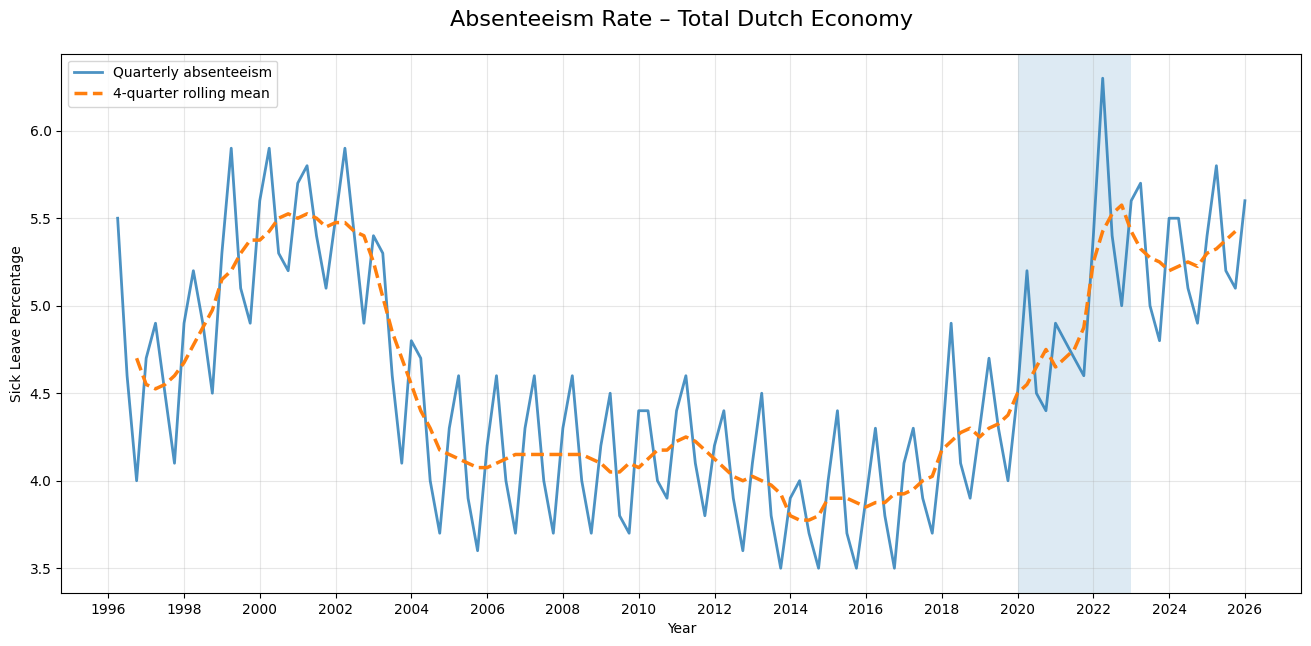

In [16]:
# ============================================================
# ENHANCED TOTAL ECONOMY TIME SERIES
# ============================================================

# Create rolling trend
df_total["rolling_mean_4q"] = (
    df_total["Ziekteverzuimpercentage_1"]
    .rolling(window=4, center=True)
    .mean()
)

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(16, 7))

# Raw quarterly series
ax.plot(
    df_total["period_enddate"],
    df_total["Ziekteverzuimpercentage_1"],
    linewidth=2,
    alpha=0.8,
    label="Quarterly absenteeism"
)

# Rolling trend
ax.plot(
    df_total["period_enddate"],
    df_total["rolling_mean_4q"],
    linestyle="--",
    linewidth=2.5,
    label="4-quarter rolling mean"
)

# ============================================================
# COVID PERIOD HIGHLIGHT
# ============================================================

ax.axvspan(
    pd.Timestamp("2020-01-01"),
    pd.Timestamp("2022-12-31"),
    alpha=0.15
)

# ============================================================
# TITLES
# ============================================================

ax.set_title(
    "Absenteeism Rate – Total Dutch Economy",
    fontsize=16,
    pad=20
)

ax.set_xlabel("Year")
ax.set_ylabel("Sick Leave Percentage")

# ============================================================
# GRID
# ============================================================

ax.grid(True, alpha=0.3)

# ============================================================
# LEGEND
# ============================================================

ax.legend()

# ============================================================
# X-AXIS FORMATTING
# ============================================================

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.show()

In [17]:
# ============================================================
# SEASONALITY ANALYSIS BY QUARTER
# ============================================================

quarterly_summary = (
    df_total.groupby("quarter")["Ziekteverzuimpercentage_1"]
    .agg([
        "mean",
        "std",
        "min",
        "max"
    ])
    .reset_index()
)

display(quarterly_summary)

,quarter,mean,std,min,max
0,1,4.993333,0.620308,4.0,6.3
1,2,4.423333,0.587621,3.7,5.4
2,3,4.153333,0.585299,3.5,5.2
3,4,4.720000,0.614985,3.9,5.7


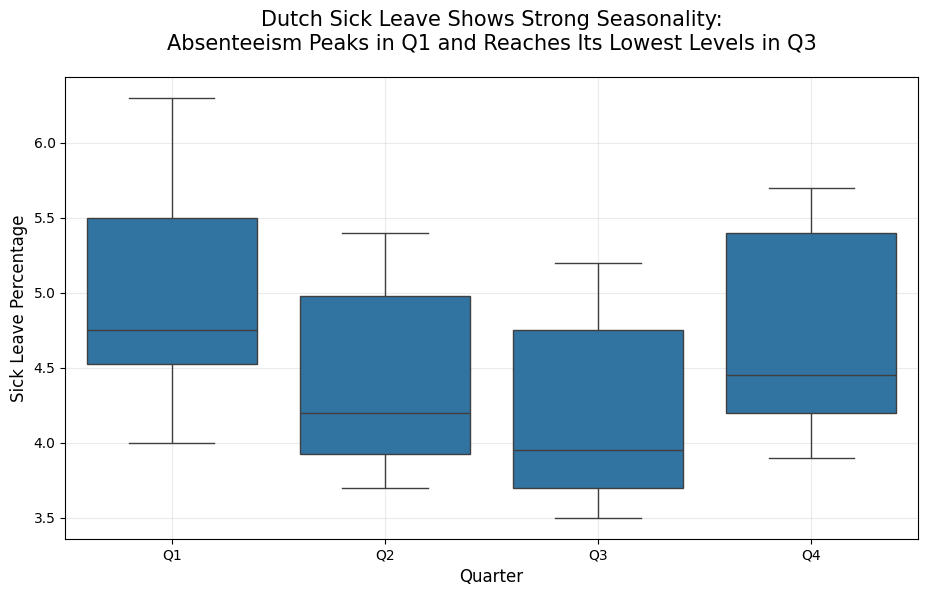

In [20]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df_total,
    x="quarter",
    y="Ziekteverzuimpercentage_1"
)

# ============================================================
# STORYTELLING TITLE
# ============================================================

plt.title(
    "Dutch Sick Leave Shows Strong Seasonality:\n"
    "Absenteeism Peaks in Q1 and Reaches Its Lowest Levels in Q3",
    fontsize=15,
    pad=20
)

# ============================================================
# LABELS
# ============================================================

plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Sick Leave Percentage", fontsize=12)

# ============================================================
# BETTER QUARTER LABELS
# ============================================================

plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["Q1", "Q2", "Q3", "Q4"]
)

# ============================================================
# GRID
# ============================================================

plt.grid(True, alpha=0.25)

plt.show()

,year,Ziekteverzuimpercentage_1
0,1996,4.700
1,1997,4.600
2,1998,4.975
3,1999,5.375
4,2000,5.525
5,2001,5.450
6,2002,5.400
7,2003,4.700
8,2004,4.175
9,2005,4.075


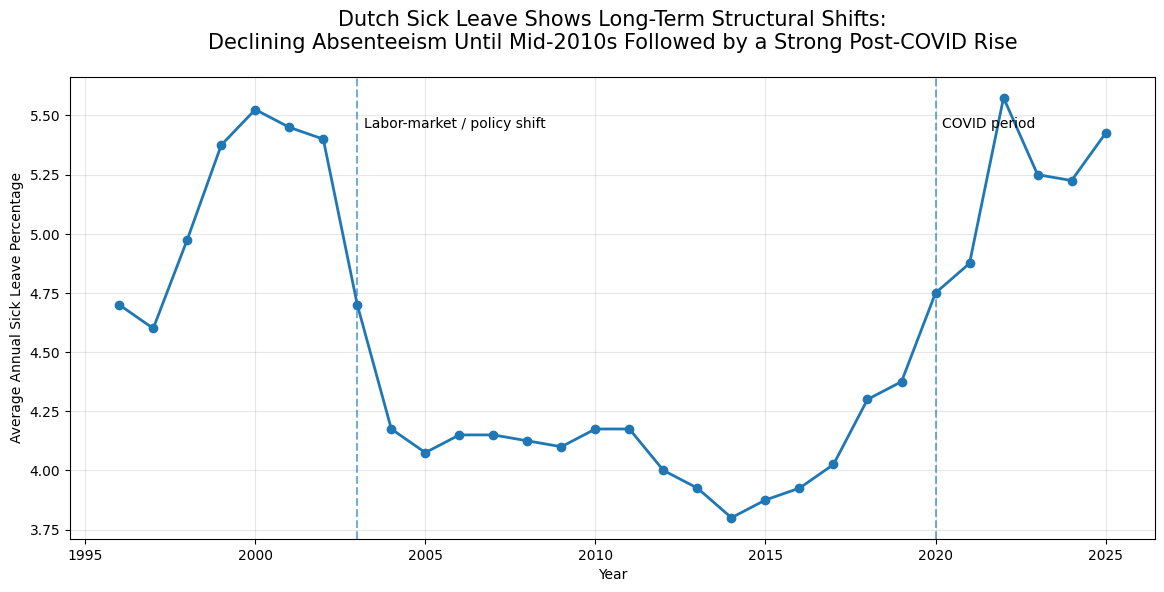

In [23]:
# ============================================================
# YEARLY ABSENTEEISM TREND
# ============================================================

yearly_trend = (
    df_total.groupby("year")["Ziekteverzuimpercentage_1"]
    .mean()
    .reset_index()
)

display(yearly_trend)

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_trend["year"],
    yearly_trend["Ziekteverzuimpercentage_1"],
    marker="o",
    linewidth=2
)

plt.title(
    "Dutch Sick Leave Shows Long-Term Structural Shifts:\n"
    "Declining Absenteeism Until Mid-2010s Followed by a Strong Post-COVID Rise",
    fontsize=15,
    pad=20
)

plt.xlabel("Year")
plt.ylabel("Average Annual Sick Leave Percentage")

plt.grid(True, alpha=0.3)

# ============================================================
# STRUCTURAL PERIOD MARKERS
# ============================================================

# Wet Verbetering Poortwachter
plt.axvline(
    2003,
    linestyle="--",
    alpha=0.6
)

# COVID start
plt.axvline(
    2020,
    linestyle="--",
    alpha=0.6
)

# ============================================================
# OPTIONAL ANNOTATIONS
# ============================================================

plt.text(
    2003.2,
    5.45,
    "Labor-market / policy shift",
    fontsize=10
)

plt.text(
    2020.2,
    5.45,
    "COVID period",
    fontsize=10
)
plt.show()

In [24]:
sector_lookup = df_q[[
    "BedrijfskenmerkenSBI2008",
    "BedrijfskenmerkenSBI2008_Title"
]].drop_duplicates()

display(sector_lookup.sort_values("BedrijfskenmerkenSBI2008_Title"))

,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title
5400,WP19078,1 tot 10 werkzame personen
5550,WP19091,10 tot 100 werkzame personen
750,307610,"10-12 Voedings-, genotmiddelenindustrie"
5700,WP19098,100 of meer werkzame personen
900,317105,17-18 Papier- en grafische industrie
1050,320005,19-22 Raffinaderijen en chemie
1200,328110,"24-30, 33 Metaal-elektro industrie"
2100,354300,45 Autohandel en -reparatie
2250,356900,46 Groothandel en handelsbemiddeling
2400,371600,47 Detailhandel (niet in auto's)


(720, 17)


,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title
0,T001081,A-U Alle economische activiteiten
600,307500,C Industrie
1650,350000,F Bouwnijverheid
2850,389100,I Horeca
4200,419000,P Onderwijs
4350,422400,Q Gezondheids- en welzijnszorg


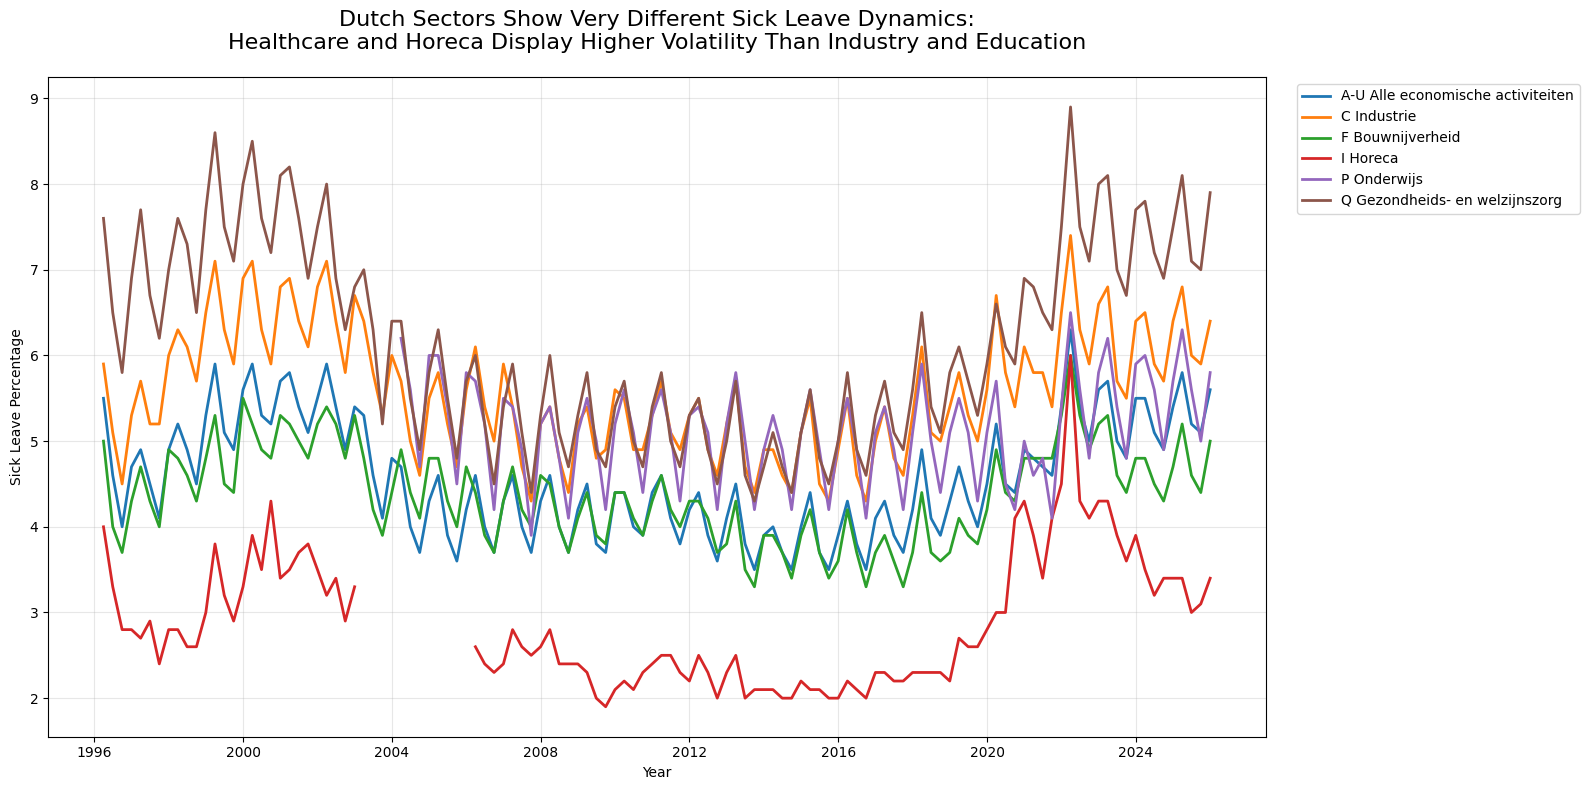

In [26]:
# ============================================================
# SELECT REPRESENTATIVE SECTORS
# ============================================================

selected_sectors = [
    "T001081",  # Total economy
    "307500",   # Industry
    "350000",   # Construction
    "389100",   # Horeca
    "419000",   # Education
    "422400"    # Healthcare
]

df_compare = df_q[
    df_q["BedrijfskenmerkenSBI2008"].isin(selected_sectors)
].copy()

print(df_compare.shape)

display(
    df_compare[[
        "BedrijfskenmerkenSBI2008",
        "BedrijfskenmerkenSBI2008_Title"
    ]].drop_duplicates()
)

plt.figure(figsize=(16, 8))

for sector_code in selected_sectors:

    sector_df = (
        df_compare[
            df_compare["BedrijfskenmerkenSBI2008"] == sector_code
        ]
        .sort_values("period_enddate")
    )

    sector_name = (
        sector_df["BedrijfskenmerkenSBI2008_Title"]
        .iloc[0]
    )

    plt.plot(
        sector_df["period_enddate"],
        sector_df["Ziekteverzuimpercentage_1"],
        linewidth=2,
        label=sector_name
    )

# ============================================================
# TITLES
# ============================================================

plt.title(
    "Dutch Sectors Show Very Different Sick Leave Dynamics:\n"
    "Healthcare and Horeca Display Higher Volatility Than Industry and Education",
    fontsize=16,
    pad=20
)

plt.xlabel("Year")
plt.ylabel("Sick Leave Percentage")

# ============================================================
# GRID + LEGEND
# ============================================================

plt.grid(True, alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [27]:
# ============================================================
# SECTOR SUMMARY TABLE
# ============================================================

sector_summary = (
    df_q.groupby([
        "BedrijfskenmerkenSBI2008",
        "BedrijfskenmerkenSBI2008_Title"
    ])["Ziekteverzuimpercentage_1"]
    .agg([
        "mean",
        "std",
        "min",
        "max",
        "count"
    ])
    .reset_index()
)

# ============================================================
# ADD MISSING VALUES
# ============================================================

missing_per_sector = (
    df_q.groupby("BedrijfskenmerkenSBI2008")[
        "Ziekteverzuimpercentage_1"
    ]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="missing_values")
)

sector_summary = sector_summary.merge(
    missing_per_sector,
    on="BedrijfskenmerkenSBI2008",
    how="left"
)

# ============================================================
# COEFFICIENT OF VARIATION
# ============================================================

sector_summary["cv"] = (
    sector_summary["std"] /
    sector_summary["mean"]
)

# ============================================================
# ROUND NUMBERS
# ============================================================

numeric_cols = [
    "mean",
    "std",
    "min",
    "max",
    "cv"
]

sector_summary[numeric_cols] = (
    sector_summary[numeric_cols]
    .round(2)
)

# ============================================================
# SORT BY VOLATILITY
# ============================================================

sector_summary = sector_summary.sort_values(
    "cv",
    ascending=False
)

display(sector_summary)

,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title,mean,std,min,max,count,missing_values,cv
36,WP19078,1 tot 10 werkzame personen,2.28,0.67,1.4,4.3,100,20,0.30
19,389100,I Horeca,2.87,0.76,1.9,6.0,108,12,0.26
21,396300,K Financiële dienstverlening,3.46,0.79,2.2,5.7,120,0,0.23
16,371600,47 Detailhandel (niet in auto's),3.71,0.84,2.0,6.2,120,0,0.23
24,410200,N Verhuur en overige zakelijke diensten,4.61,1.06,3.2,7.1,104,16,0.23
10,346600,D Energievoorziening,4.64,0.99,3.0,7.8,104,16,0.21
3,301000,"A Landbouw, bosbouw en visserij",2.98,0.64,1.7,4.5,120,0,0.21
29,422500,86 Gezondheidszorg,5.25,1.03,3.6,7.8,104,16,0.20
4,305700,B Delfstoffenwinning,3.73,0.73,2.4,5.6,120,0,0.20
28,422400,Q Gezondheids- en welzijnszorg,6.16,1.16,4.3,8.9,120,0,0.19


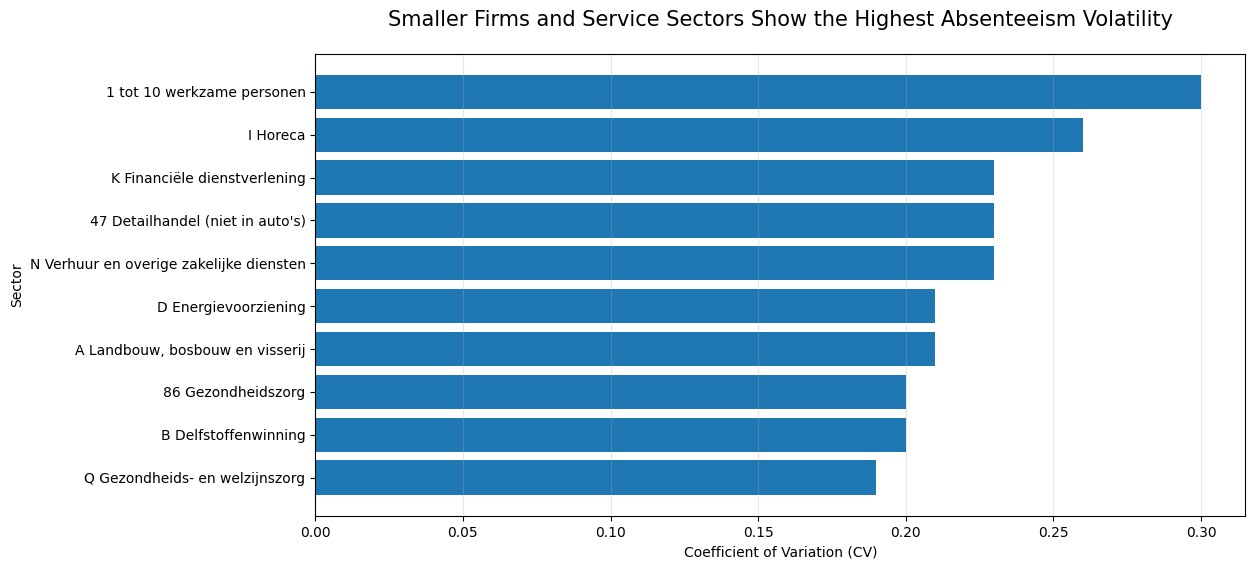

In [28]:
# ============================================================
# TOP VOLATILE SECTORS
# ============================================================

top_volatile = (
    sector_summary
    .sort_values("cv", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_volatile["BedrijfskenmerkenSBI2008_Title"],
    top_volatile["cv"]
)

plt.gca().invert_yaxis()

plt.title(
    "Smaller Firms and Service Sectors Show the Highest Absenteeism Volatility",
    fontsize=15,
    pad=20
)

plt.xlabel("Coefficient of Variation (CV)")
plt.ylabel("Sector")

plt.grid(True, axis="x", alpha=0.3)

plt.show()

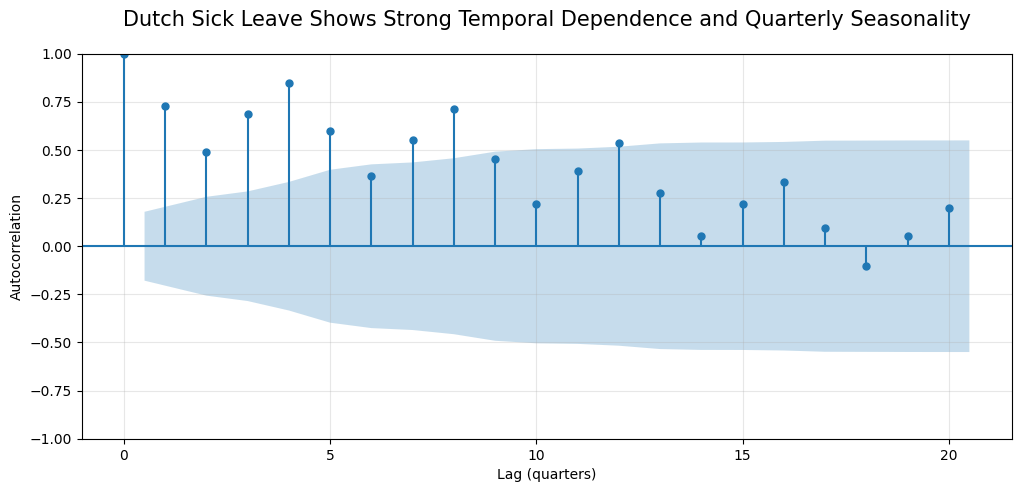

In [29]:
from statsmodels.graphics.tsaplots import plot_acf

# ============================================================
# AUTOCORRELATION ANALYSIS
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    df_total["Ziekteverzuimpercentage_1"],
    lags=20,
    ax=ax
)

plt.title(
    "Dutch Sick Leave Shows Strong Temporal Dependence and Quarterly Seasonality",
    fontsize=15,
    pad=20
)

plt.xlabel("Lag (quarters)")
plt.ylabel("Autocorrelation")

plt.grid(True, alpha=0.3)

plt.show()

In [30]:
from statsmodels.tsa.stattools import adfuller

# ============================================================
# ADF TEST
# ============================================================

adf_result = adfuller(
    df_total["Ziekteverzuimpercentage_1"]
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 80)
print("AUGMENTED DICKEY-FULLER TEST")
print("=" * 80)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"N Observations: {adf_result[3]}")

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

AUGMENTED DICKEY-FULLER TEST
ADF Statistic : -1.9332
p-value       : 0.3166
Lags Used     : 12
N Observations: 107

Critical Values:
  1%: -3.4930
  5%: -2.8890
  10%: -2.5814


# Notebook Summary — Understanding 80072NED

## Objective
Explore and understand the CBS absenteeism dataset (`80072ned_silver`) before building forecasting models.

---

# Main Activities

## Data Understanding
- Loaded and inspected the full dataset structure
- Reviewed:
  - row granularity
  - column types
  - missing values
  - sector hierarchy
  - temporal structure

## Time Preparation
- Converted CBS `Perioden` field into:
  - frequency
  - year
  - quarter
  - `period_enddate`
- Filtered dataset to quarterly observations only for forecasting consistency

## Sector Hierarchy Analysis
- Investigated SBI sector aggregation levels
- Identified:
  - total economy level
  - sector groups
  - detailed subsectors
  - company size categories

## Missing Value Analysis
- Evaluated missing target values across sectors
- Observed that missingness is concentrated in specific sectors and periods rather than uniformly distributed

## Exploratory Time-Series Analysis

### Total Economy Analysis
Analyzed absenteeism for:
- `T001081 — A-U Alle economische activiteiten`

Key findings:
- strong quarterly seasonality
- long-term structural shifts
- decline until mid-2010s
- strong increase after COVID-19

### Seasonality Analysis
Quarterly patterns show:
- Q1 and Q4 consistently higher absenteeism
- Q3 consistently lowest absenteeism

### Sector Comparison
Compared representative sectors including:
- healthcare
- horeca
- construction
- education
- industry

Observed:
- large differences in volatility
- different baseline absenteeism levels
- sector-specific dynamics

## Statistical Diagnostics

### Autocorrelation (ACF)
The series shows:
- strong temporal dependence
- repeating seasonal structure
- forecasting potential

### Stationarity Test (ADF)
ADF test indicates:
- the total economy series is non-stationary
- trend and structural changes are present
- differencing will likely be required for SARIMA modeling

---

# Key Conclusions

- Sick leave is strongly seasonal and time-dependent
- Forecasting based on historical values is feasible
- Structural regime changes exist after 2019/COVID
- Sector-level forecasting may provide additional value
- Statistical forecasting models should account for:
  - seasonality
  - trend
  - structural shifts
  - sector heterogeneity

---

# Next Step
Proceed to:

`06_02_time_series_baselines.ipynb`

Focus:
- baseline forecasting models
- train/test strategy
- walk-forward validation
- SARIMA / ETS baselines